/tmp/ipykernel_4526/78991033.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.scatterplot(x=x, y=y, hue=None, palette="viridis", legend=None, edgecolor=None, alpha=0.4, s=3)  # Adjust dot size with `s`


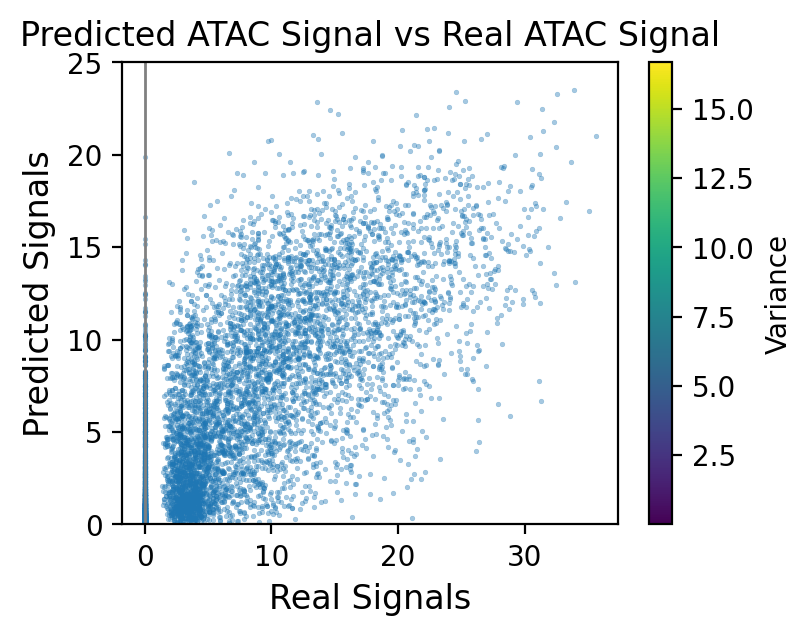

Pearson correlation coefficient: 0.7628606353068608
Spearman correlation coefficient: 0.7919875747001625
P-value: 0.0


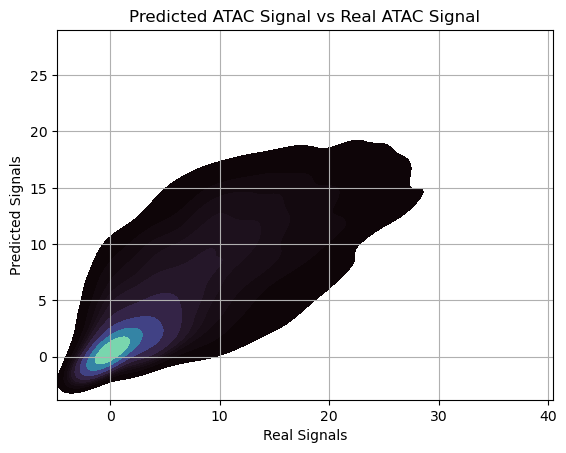

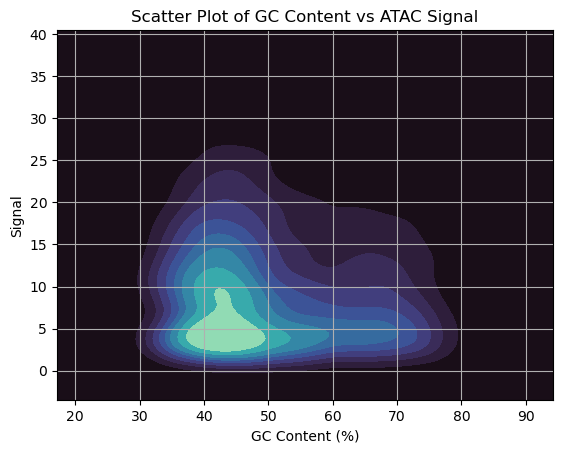

Signal and GC SignificanceResult(statistic=-0.08229420889839961, pvalue=1.682049951712524e-09)


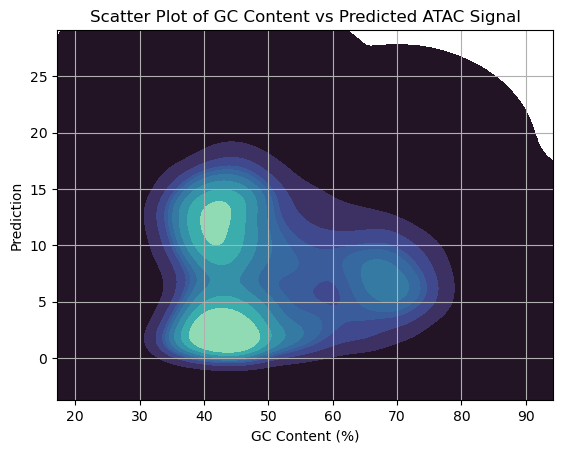

Prediction and GC SignificanceResult(statistic=0.026667473180227625, pvalue=0.01606744494513832)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

############################################################################################
sns.kdeplot(x=x, y=y, fill=True,cmap="mako")
plt.title('Predicted ATAC Signal vs Real ATAC Signal')
plt.xlabel('Real Signals')
plt.ylabel('Predicted Signals')
plt.grid(True)
plt.show()

###############################################################################################
import pandas as pd
from Bio import SeqIO
import seaborn as sns
# Assuming df_mpra_prediction is your DataFrame and enhancer_seq is the column with DNA sequences
def calculate_gc_content(seq):
    # Calculate the number of G's and C's in the sequence
    seq=seq.upper()
    gc_count = seq.count('G') + seq.count('C')
    # Calculate GC content as a percentage of the total sequence length
    return (gc_count / len(seq)) * 100 if len(seq) > 0 else 0

def fasta_to_dataframe(fasta_file):
    # Parse the FASTA file
    sequences = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        sequences.append({"ID": record.id, "Sequence": str(record.seq)})

    # Convert list of dicts into a DataFrame
    df = pd.DataFrame(sequences)
    
    return df.set_index("ID")

# Example usage
pos = fasta_to_dataframe('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_fasta_hg38/HEK293T_ATAC.idr.optimal_peak.narrowPeak.validation.bed.fasta')
neg = fasta_to_dataframe('/media/zihengc/T7/THP1_machinelearning/background_negatives_500bp_hg38/HEK293T_ATAC.idr.optimal_peak.expand_500bp_hg38_biasaway_GCmatch_background_noOverlap_validation.fasta')
df = pd.concat([pos,neg])
df["Prediction"] = df_pred.mean(axis=1).tolist()
df['GC_content'] =df['Sequence'].apply(calculate_gc_content)
df['Signal'] = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/HEK293T_ATAC.idr.optimal_peak.narrowPeak.validation.withNeg.bed',sep='\t',header=None )[6].tolist()
df_pos = df[df['Signal']!=0]
###################Look at GC content and original ATAC signal##########################
import scipy
# Assuming df_mpra_prediction is your DataFrame
# Ensure 'mad_score' is replaced with the actual column name for the score if different
sns.kdeplot(x=df_pos['GC_content'], y=df_pos['Signal'], fill=True, thresh=0, levels=10, cmap="mako")
#plt.scatter(df_pos['GC_content'], df_pos['Signal'], s=5, edgecolor='w', linewidth=0.5, cmap='viridis', alpha=0.5)
plt.title('Scatter Plot of GC Content vs ATAC Signal')
plt.xlabel('GC Content (%)')
plt.ylabel('Signal')
plt.grid(True)
plt.show()
print("Signal and GC", scipy.stats.spearmanr(df_pos[['GC_content','Signal']]))
####################Look at GC content and predicted ATAC signal########################
import scipy
# Assuming df_mpra_prediction is your DataFrame
# Ensure 'mad_score' is replaced with the actual column name for the score if different
#plt.scatter(df['GC_content'], df['Prediction'], s=5, edgecolor='w', linewidth=0.5, cmap='viridis', alpha=0.5)
sns.kdeplot(x=df_pos['GC_content'], y=df_pos['Prediction'], fill=True, thresh=0, levels=10, cmap="mako")
plt.title('Scatter Plot of GC Content vs Predicted ATAC Signal')
plt.xlabel('GC Content (%)')
plt.ylabel('Prediction')
plt.grid(True)
plt.show()
print("Prediction and GC", scipy.stats.spearmanr(df[['GC_content','Prediction']]))

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

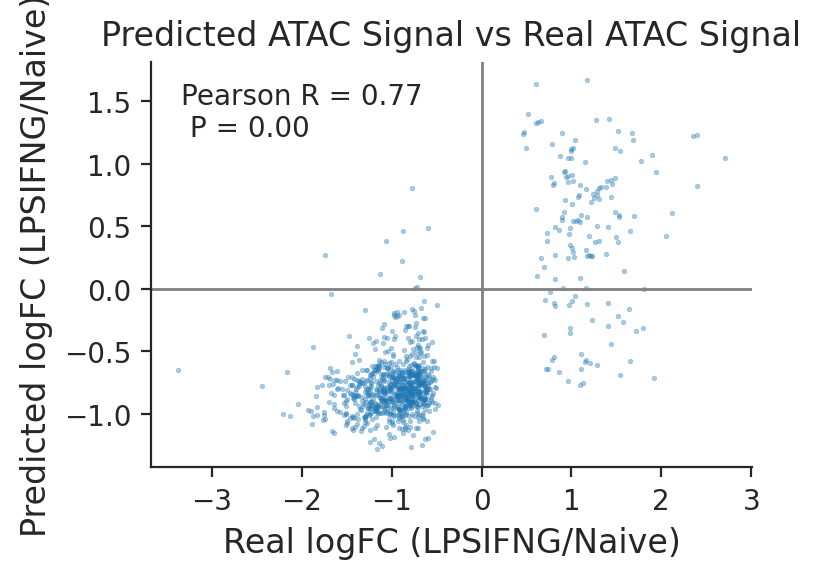

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr

# ---------------------------
# Load your data (as in your code)
df_pred_neg = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/prediction/State-differential/THP1_LPSIFNGvsNaive-model-best_THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.validation.enhancer.csv', sep='\t', header=None)
df_pred_pos = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/prediction/State-differential/THP1_LPSIFNGvsNaive-model-best_THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.validation.enhancer.csv', sep='\t', header=None)
df_pred = pd.concat([df_pred_pos, df_pred_neg])

df_real_neg = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38_enhancer_10kbfromTSS/THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.validation.enhancer.bed', sep='\t', header=None)[6]
df_real_pos = pd.read_csv('/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38_enhancer_10kbfromTSS/THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.validation.enhancer.bed', sep='\t', header=None)[6]
df_real = pd.concat([df_real_pos, df_real_neg])

df_pred = pd.DataFrame([df_pred.iloc[0::2, 0].tolist(),
                        df_pred.iloc[1::2, 0].tolist()]).T

# Convert to lists for plotting
x = df_real.tolist()
y = df_pred.mean(axis=1).tolist()

# ---------------------------
# Compute correlations
pearson_corr, p = pearsonr(x, y)
spearman_corr, _ = spearmanr(x, y)

# ---------------------------
# Create the plot
plt.figure(figsize=(4, 3), dpi=200)
sns.set_style("ticks")  # Minimal axes

ax = sns.scatterplot(
    x=x,
    y=y,
    edgecolor=None,
    alpha=0.4,
    s=3
)

# Add lines at zero if desired
plt.axhline(0, color='gray', lw=1)
plt.axvline(0, color='gray', lw=1)

# Annotate correlations
corr_text = f"Pearson R = {pearson_corr:.2f}\n P = {p:.2f}"
ax.text(
    0.05,
    0.95,
    corr_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

# Label and title
plt.xlabel('Real logFC (LPSIFNG/Naive)', fontsize=12)
plt.ylabel('Predicted logFC (LPSIFNG/Naive)', fontsize=12)
plt.title('Predicted ATAC Signal vs Real ATAC Signal', fontsize=12)

sns.despine()  # Remove top/right spines for a cleaner look
plt.tight_layout()
plt.savefig('LPSIFNGvsNaive_scatter_enhancer_plot.pdf',dpi=300)
plt.show()


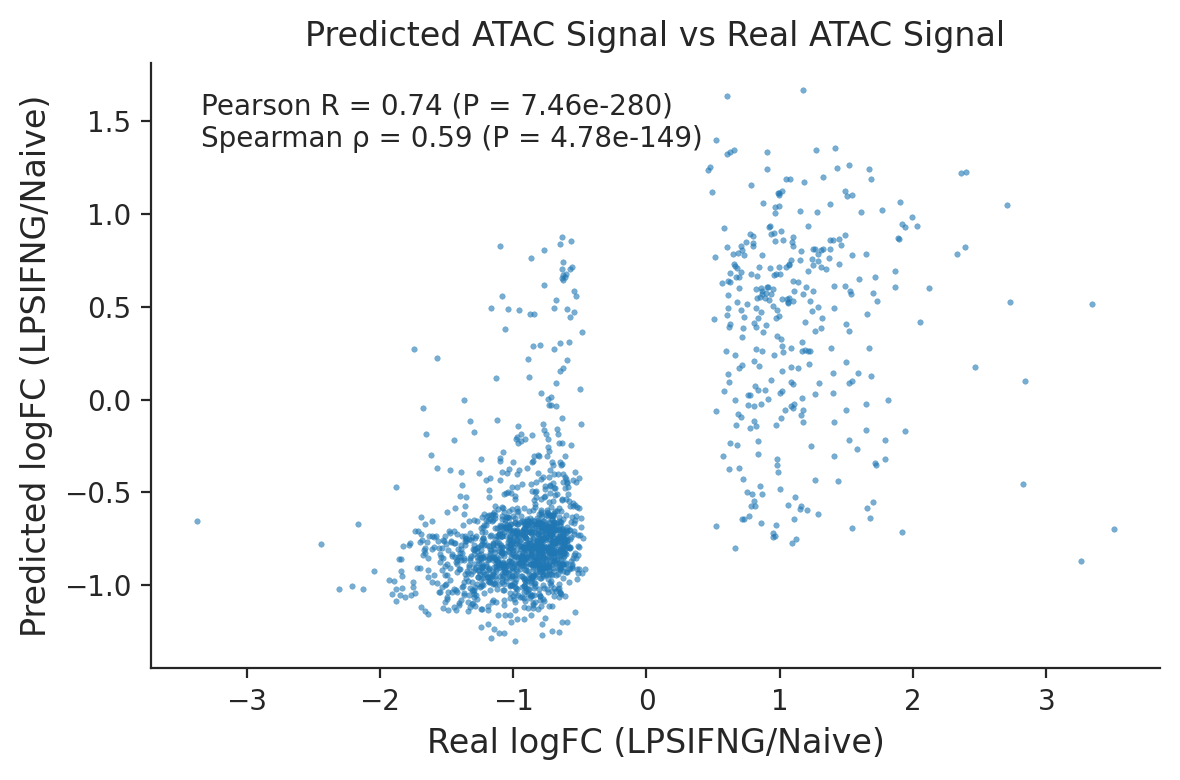

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# ──────────────────────────────────────────────────────────────
# 0  Load data
# ──────────────────────────────────────────────────────────────
df_pred_neg = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/prediction/state-differential/'
    'THP1_LPSIFNGvsNaive-model-best_THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.validation.csv',
    sep='\t', header=None
)
df_pred_pos = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/prediction/state-differential/'
    'THP1_LPSIFNGvsNaive-model-best_THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.validation.csv',
    sep='\t', header=None
)
df_pred = pd.concat([df_pred_pos, df_pred_neg])

df_real_neg = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/'
    'THP1_LPSIFNG_vs_Naive_neg.idr.optimal_peak.narrowPeak.validation.bed',
    sep='\t', header=None
)[6]
df_real_pos = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/expand_peaks_500bp_hg38/'
    'THP1_LPSIFNG_vs_Naive_pos.idr.optimal_peak.narrowPeak.validation.bed',
    sep='\t', header=None
)[6]
df_real = pd.concat([df_real_pos, df_real_neg])

# average the two prediction replicates
df_pred = pd.DataFrame({
    'pred1': df_pred.iloc[0::2, 0].values,
    'pred2': df_pred.iloc[1::2, 0].values
})
x = df_real.values
y = df_pred.mean(axis=1).values

# ──────────────────────────────────────────────────────────────
# 1  Compute correlations
# ──────────────────────────────────────────────────────────────
pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

# ──────────────────────────────────────────────────────────────
# 2  Make the scatter plot
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 4), dpi=200)
sns.set_style("ticks")

ax = sns.scatterplot(x=x, y=y, alpha=0.6, s=4, edgecolor=None)

# Annotate both correlations
corr_text = (
    f"Pearson R = {pearson_r:.2f} (P = {pearson_p:.2e})\n"
    f"Spearman ρ = {spearman_rho:.2f} (P = {spearman_p:.2e})"
)
ax.text(
    0.05, 0.95, corr_text,
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.6)
)

# Labels and styling
ax.set_xlabel('Real logFC (LPSIFNG/Naive)', fontsize=12)
ax.set_ylabel('Predicted logFC (LPSIFNG/Naive)', fontsize=12)
ax.set_title('Predicted ATAC Signal vs Real ATAC Signal', fontsize=12)
sns.despine()
plt.tight_layout()

# Save and show
plt.savefig('LPSIFNGvsNaive_scatter_plot.pdf', dpi=300)
plt.show()
